Introduction

The objective of this project is to predict whether a bank customer will leave the bank (churn) or continue using the services.

Customer churn prediction is a supervised machine learning classification problem, where the target variable indicates whether a customer has exited.

We will:

Clean and preprocess the dataset
Perform exploratory data analysis (EDA)
Encode categorical variables
Train a classification model
Evaluate model performance
Identify important features influencing churn

Dataset Overview

The dataset contains information about bank customers including demographic, financial, and account-related features.

Key Features:
CreditScore: Customer credit score
Geography: Country (France, Spain, Germany)
Gender: Male/Female
Age: Customer age
Tenure: Years with bank
Balance: Account balance
NumOfProducts: Number of bank products used
HasCrCard: Credit card ownership
IsActiveMember: Activity status
EstimatedSalary: Income estimate
Exited: Target variable (1 = churn, 0 = stay)

In [1]:
#Here we load python libraries required for executing this task
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns



from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score 


# here we load our CSV Dataset that we downloaded from Kaggle 
# Dataset link: https://www.kaggle.com/datasets/shrutimechlearn/churn-modelling

df = pd.read_csv("Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
#DataSet Understanding - 
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Observation: 
Dataset has no missing values
All features are complete
Mix of categorical and numerical data

In [3]:
#Data Cleaning 
#data cleaning is a very important part of a Data Science And Analytics project.If you input cleaned
# data into your system, you get meaningfull insights , if your data is noisy, your output will be
# biased, inaccurate and inconsistent

#Here we remove unimportant columns that do not contribute to the final results or analysis
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
df.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


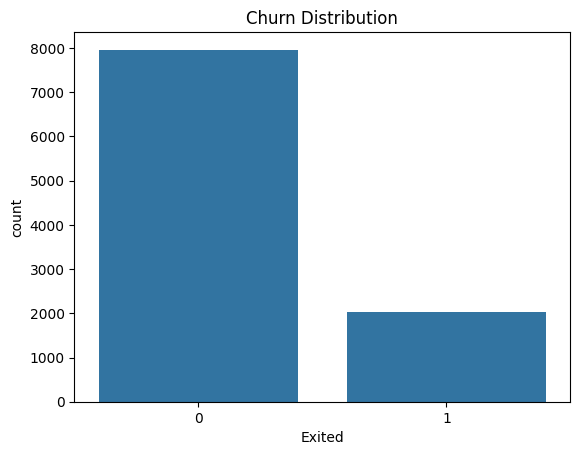

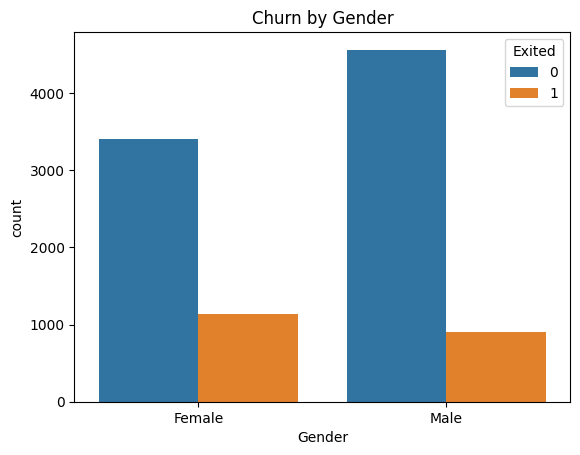

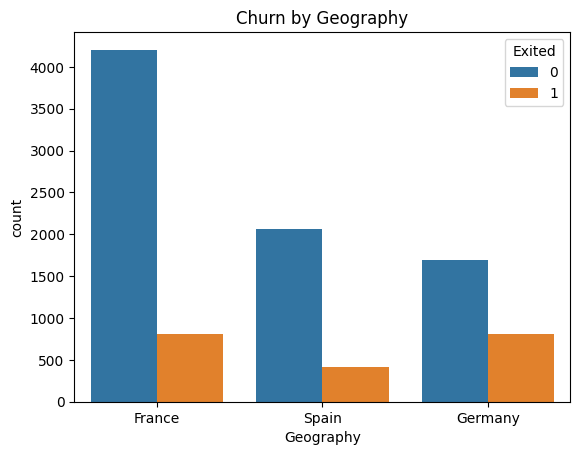

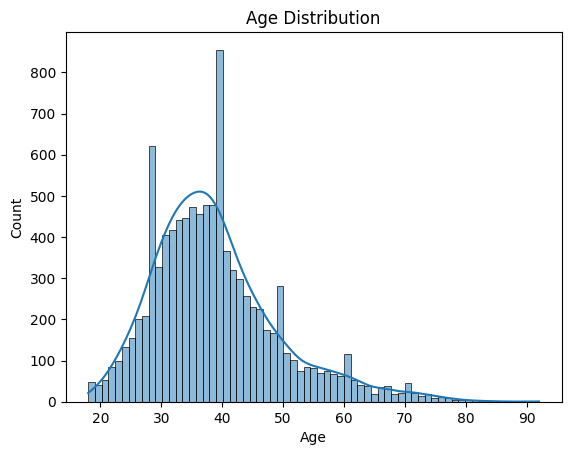

In [4]:
#EDA
#Churn Distribution
sns.countplot(x='Exited', data=df)
plt.title("Churn Distribution")
plt.show()

#Observation: Dataset is imbalanced (more non-churn customers)

#Churn By Gender
sns.countplot(x='Gender', hue='Exited', data=df)
plt.title("Churn by Gender")
plt.show()

#Insight: Female customers show slightly higher churn tendency

#Churn By Geography
sns.countplot(x='Geography', hue='Exited', data=df)
plt.title("Churn by Geography")
plt.show()

#Insight: Germany has higher churn rate compared to France and Spain

#Age Distribution

sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

#Insight: Middle-aged customers dominate dataset





Now We convert categorical variables into numeric form:
Gender → Label Encoding
Geography → One-Hot Encoding

In [5]:
#Encoding Categorical Variables

# Label Encoding for Gender
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# One-hot encoding for Geography
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [6]:
#Train - Test Split

X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Feature Scaling:
in this process, We scale numerical features to improve model performance and make it more accurate.

In [7]:
#Feature Scaling

#Feature scaling improves model performance for numerical stability.


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



Model Training (Random Forest)

Random Forest is chosen because:

Handles non-linear relationships
Works well on tabular data
Provides feature importance

In [8]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [9]:
#Model Evaluation

#Accuracy

print("Accuracy:", accuracy_score(y_test, y_pred))

#Confusion matrix

print(confusion_matrix(y_test, y_pred))

#ROC - AUC Score

roc_auc_score(y_test, y_pred)




Accuracy: 0.8665
[[1551   56]
 [ 211  182]]


0.7141283918480059

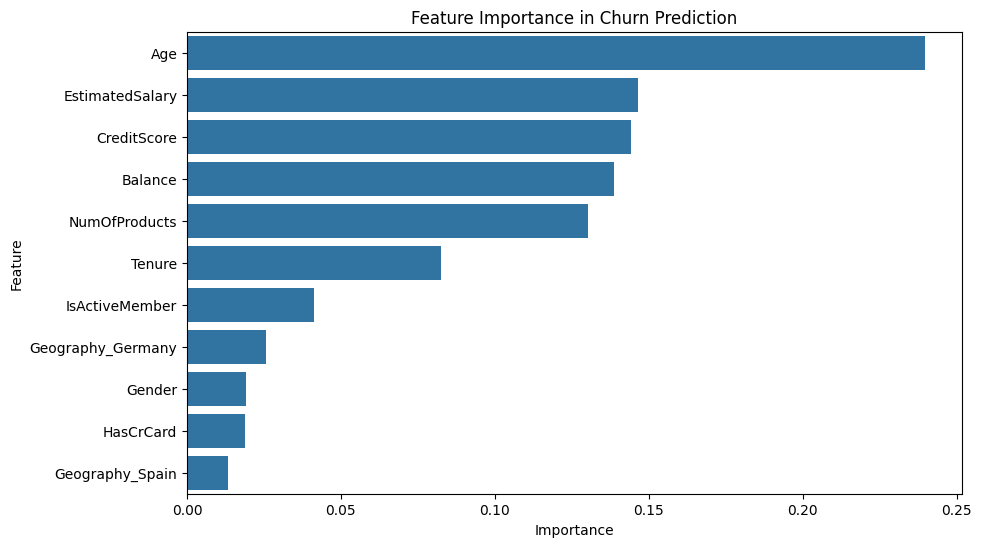

In [10]:
#Feature Importance

importances = model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title("Feature Importance in Churn Prediction")
plt.show()

Key Insights

From the model and EDA, we conclude:

Age is a strong predictor of churn
Customers from Germany have higher churn rates
Inactive members are more likely to leave
Credit score and balance also influence churn behavior
Random Forest achieved strong performance (~86% accuracy)

Conclusion
This project successfully built a customer churn prediction model using machine learning.
We:
Cleaned and prepared the dataset
Performed meaningful exploratory analysis
Encoded and scaled features
Trained a Random Forest classifier
Evaluated performance using multiple metrics
Identified key churn-driving factors
Final Outcome:
The model can help banks identify customers at risk of leaving, enabling proactive retention strategies.